In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# K Means Clustering

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
X,y_true = make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)

In [4]:
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [5]:
scale = StandardScaler()
X_scaled = scale.fit_transform(df)

In [6]:
inertia = [] # wcss
K_range = range(1,11) 

In [7]:
for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

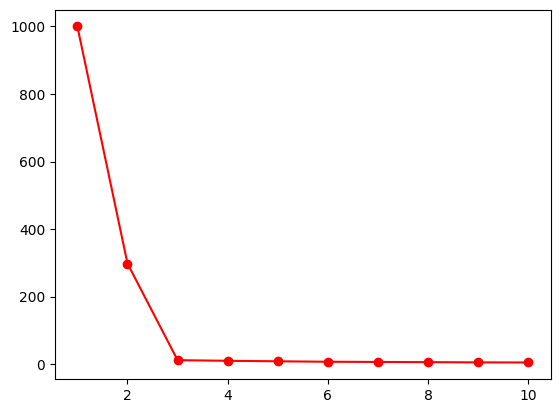

In [8]:
plt.plot(K_range,inertia,marker = 'o',color = 'red')

In [9]:
kmeans_final = KMeans(n_clusters=3,random_state=42)

In [10]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [11]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

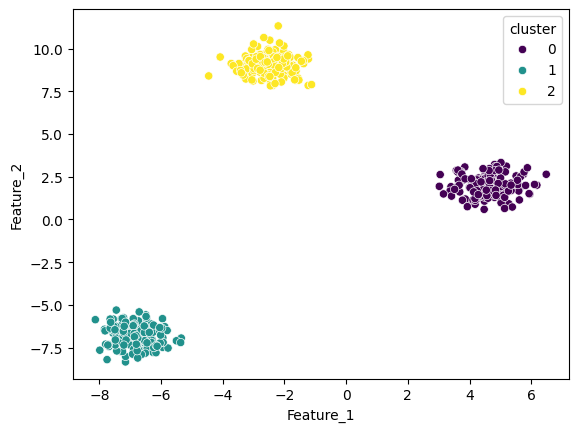

In [12]:
sns.scatterplot(x = df['Feature_1'] , y = df['Feature_2'] , hue = df['cluster'],palette='viridis')

# DBSCAN

In [13]:
from sklearn.datasets import make_moons

In [14]:
X,y_true = make_moons(n_samples=500,noise=0.05,random_state=42)

In [15]:
X

array([[ 0.83058575, -0.44773257],
       [ 0.70167816,  0.81691843],
       [ 1.02208004, -0.49257102],
       [-0.31676455,  0.95343844],
       [ 0.29322631,  1.05718523],
       [ 1.25490304, -0.48343549],
       [ 1.05385133, -0.44269047],
       [ 0.03137971,  1.05301203],
       [ 0.62054473,  0.71309598],
       [ 1.7876566 , -0.14295878],
       [ 0.99907493,  0.09180641],
       [-0.70723041,  0.57499903],
       [ 1.46479643, -0.47111862],
       [ 0.42712245,  0.83103216],
       [ 1.05341942, -0.50102941],
       [ 1.19597671, -0.49472393],
       [ 1.99422286,  0.42426007],
       [ 0.93175527,  0.39426183],
       [ 0.41104275, -0.33348189],
       [ 1.49073255, -0.38560138],
       [ 1.97517181,  0.35930615],
       [ 2.0470942 ,  0.41068552],
       [-0.00592133,  0.14862165],
       [ 0.82592072, -0.42998975],
       [ 0.54309448,  0.75144817],
       [ 1.8709548 ,  0.20141701],
       [ 1.9224317 ,  0.43263225],
       [-0.86765136,  0.45505598],
       [ 0.28216036,

In [16]:
from sklearn.cluster import KMeans,DBSCAN

In [17]:
df = pd.DataFrame(X,columns=['Feat1','Feat2'])

In [18]:
df

,Feat1,Feat2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
...,...,...
495,0.239754,0.985462
496,0.072145,0.184834
497,0.590273,-0.365577
498,1.619465,-0.283658


In [19]:
X_scaled = scale.fit_transform(df)

In [21]:
Kmeans = KMeans(n_clusters=2,random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [22]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feat1', ylabel='Feat2'>

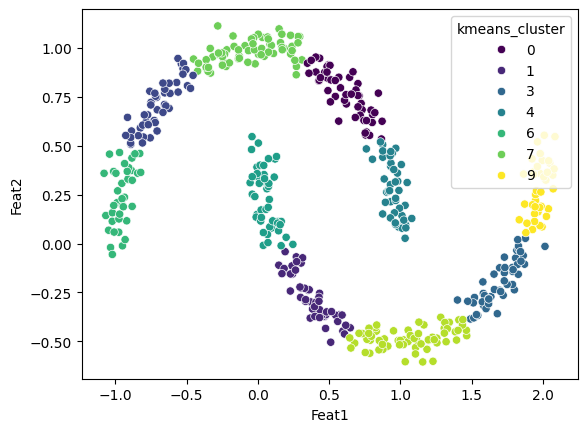

In [23]:
sns.scatterplot(x = df['Feat1'] , y = df['Feat2'] , hue = df['kmeans_cluster'],palette='viridis')

In [24]:
dbscan = DBSCAN(eps=0.3 , min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [25]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feat1', ylabel='Feat2'>

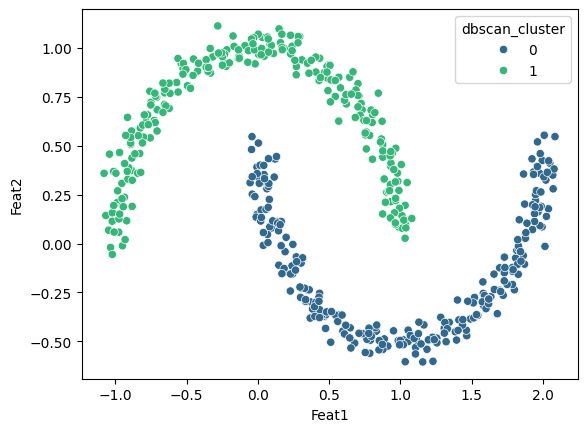

In [26]:
sns.scatterplot(x = df['Feat1'] , y = df['Feat2'] , hue = df['dbscan_cluster'],palette='viridis')

# Dimentionality Reduction & PCA

In [28]:
from sklearn.decomposition import PCA

In [29]:
X,y = make_blobs(n_samples=500,n_features=5,centers=3,cluster_std=1.5,random_state=42)

In [30]:
X

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]])

In [31]:
X_scaled = scale.fit_transform(X)

In [32]:
X_scaled

array([[-1.07039133,  0.74546814,  0.0859273 , -1.58466105, -0.90798501],
       [-0.52251206,  0.61451192,  0.08731966, -0.95761934, -0.68801347],
       [ 0.78222538,  0.4223533 , -1.04593191,  0.20984645, -0.76407462],
       ...,
       [ 0.14922774, -1.22161917,  0.65212732,  0.82409945,  1.98001159],
       [ 1.16073493,  0.7636525 , -0.01629411,  0.39814317, -0.84828797],
       [-0.70166364, -1.61902103,  1.11350971,  1.38647649,  1.30212699]])

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [34]:
X_pca

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

In [35]:
df_pca = pd.DataFrame(X_pca,columns = ['PCA1','PCA2'])
df_pca['label'] = y

In [ ]:
sns.scatterplot